During primary data collection analysis, a positive relationship between error rate and accuracy differential between V-BReE and GPT-OSS-20b, the highest performance constituent model during testing, was noted.  It is hypothesized that errors effectively reset the variance, allowing the ensemble to process the responses for longer and arrive at higher quality final responses.

To investigate this hypothesis, we will reprocess a sub-sample containing 360 items that were answered correctly and without processing errors during  initial analysis, and 360 items that were answered incorrectly and without processing errors during initial analysis.  This subset of 720 total questions will be processed using extended variance thresholds that allow for more processing cycles.  The resulting data will then be compared to the original results to look for changes in performance, both overall and comparatively with GPT-OSS-20b

# Processing workflow for collecting data on V-BReE performance using the MMLU-PRO dataset.

## 1. Adding the V-BReE framework to a workspace

### Import the V-BReE module from Github
To install the V-BReE module, clone the git repository into the colab file system.

---

*If you run into problems with folder naming, you should be able to delete or rename the existing folder and then create a fresh clone*

In [84]:
from pathlib import Path

vbree_path = Path("v_bree.py")

if not vbree_path.is_file():
  !wget https://raw.githubusercontent.com/JasonIves/V-BReE/main/v_bree.py

### Import the module

You can now import the *v_bree* module.

In [85]:
import v_bree

## 2. Configuring the V-BReE framework workspace

### Store inference connection API key
Modeling and inference connections often require an API key.  That key can be stored in the "Secrets" section of the sidebar, given a name, and then referenced using the *userdata* library.  This example represents a HuggingFace Inference Client key, but other services should work similarly.

Do not store API keys directly in code.

Once the token is stored you will need to give the notebook permission to access it.

In [86]:
from google.colab import userdata

hfToken = userdata.get('HF_TOKEN')

### Define inference connection client

Define a client connection that uses the OpenAI API format.  Primary testing for this module was done using the [Hugging Face Inference Client](https://huggingface.co/docs/huggingface_hub/en/package_reference/inference_client), but other clients utilizing the OpenAI API format should work as well.


In [87]:
from huggingface_hub import InferenceClient

client = InferenceClient(
              provider = "auto",
              api_key = hfToken
          )

## 3. Working with the V-BReE framework

### General system configuration

As usual, finishing outfitting the workspace with the necessary Python tools.


In [88]:
import json
import re
import random

import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset

### Create a sub-sample of cases without errors for further testing.

For this investigation, we will load a subset of 720 cases, 360 that were correct in initial testing, and 360 that were incorrect.  These cases will be drawn from a overall subset of questions that did not, in initial testing, trigger LaTeX formatting errors.  This exclusion is an attempt to avoid the confouding variable of error introduction, and instead to focus on intentional extension of the processing window.

Our hope is that this experiment provides insight into what is driving the observed positive relationship between error rate and performance differential vs GPT-OSS-20B.

- 720 cases
- 30 each from 12 separate categories
  - biology
  - business
  - chemistry
  - computers
  - economics
  - history
  - law
  - math
  - philosophy
  - physics
  - engineering
  - psychology

In [89]:
##DEFINE THE DOMAINS FOR ANALYSIS
all_domains = ["biology", "business", "chemistry", "computer science", "economics", "history", "law", "math", "philosophy", "physics", "engineering", "psychology"]

##LOAD THE MAIN DATA SET
dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test")
data = dataset.to_pandas()

##LOAD THE INITIAL TESTING RESULTS FROM GITHUB INTO FILE STORAGE
if not Path("v-bree_mmlupro_test_0_3000_20260306_final.csv").is_file():
  !wget https://raw.githubusercontent.com/JasonIves/V-BReE/main/data/full_sample_results/v-bree_mmlupro_test_0_3000_20260306_final.csv

orig_results = pd.read_csv("v-bree_mmlupro_test_0_3000_20260306_final.csv")

##SUBSET THE RESULTS FOR CASES WITHOUT ERRORS
cases_w_errors = orig_results[orig_results["updated_answer"] == "Error"]["id"].unique()
ne_results = orig_results[~orig_results["id"].isin(cases_w_errors)]

##MERGE THE CORRECT ANSWERS TO THE DATA
ne_merged = pd.merge(ne_results, data[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")

##IDENTIFY INCORRECT CASES FROM NON-ERROR SUBSET
incorrect_sample_ids = ne_merged[(ne_merged["answer"] != ne_merged["selected_choice"]) & ne_merged["chosen_response"] == True]["id"].unique()

##SAMPLE 360 FROM CORRECT AND INCORRECT NON-ERROR CASES, 30 FROM EACH DOMAIN
correct_sample = []
incorrect_sample = []
for domain in all_domains:
  domain_correct_ids = ne_merged[(ne_merged["answer"] == ne_merged["selected_choice"]) & ne_merged["chosen_response"] == True & (ne_merged["domain"] == domain)]["id"].unique()
  domain_incorrect_ids = ne_merged[(ne_merged["answer"] != ne_merged["selected_choice"]) & ne_merged["chosen_response"] == True & (ne_merged["domain"] == domain)]["id"].unique()

  domain_correct_sample_ids = random.sample(list(domain_correct_ids), 30)
  domain_incorrect_sample_ids = random.sample(list(domain_incorrect_ids), 30)

  correct_sample.extend(domain_correct_sample_ids)
  incorrect_sample.extend(domain_incorrect_sample_ids)

##CREATE SAMPLE
sample_ids = correct_sample + incorrect_sample
sample_ids.sort()
sample = ne_results[(ne_results["id"].isin(sample_ids)) & (ne_results["iteration"] == 0)]

sample = sample.sort_values("id")
sample = sample.reset_index(drop = True)

print(sample.head(5))


   Unnamed: 0   id  iteration                                      model  \
0        4712   76          0          Qwen/Qwen2.5-7B-Instruct:together   
1        9468   77          0                    openai/gpt-oss-20b:groq   
2        5589   85          0  meta-llama/Llama-3.1-8B-Instruct:cerebras   
3        8062   95          0  meta-llama/Llama-3.1-8B-Instruct:cerebras   
4        9159  106          0                    openai/gpt-oss-20b:groq   

                                            question  \
0   Pine and Gilmore (1999) derive four distinct ...   
1   Which type of research methods are designed t...   
2  How does lateral communication in an organisat...   
3  Where in the balance sheet does each of the fo...   
4  The Five Star Hotel put down $3,000 worth of c...   

                                             choices    domain  prompt_tokens  \
0  ['Customer participation and environmental acq...  business            275   
1  ['Non-probability.', 'Cross-sectional.', 

### Configure options as lists



In [90]:
##REFORMAT OPTIONS COLUMN TO ENSURE LIST STRUCTURE
sample["choices"] = sample["choices"].apply(ast.literal_eval)

display(sample)

,Unnamed: 0,id,iteration,model,question,choices,domain,prompt_tokens,previous_answer,updated_answer,selected_choice,response_tokens,scoring_model,score,score_moving_avg,score_moving_variance,chosen_response,confidence_score
0,4712,76,0,Qwen/Qwen2.5-7B-Instruct:together,Pine and Gilmore (1999) derive four distinct ...,[Customer participation and environmental acqu...,business,275,NaN,Pine and Gilmore (1999) derive four distinct r...,D,49,meta-llama/Llama-3.1-8B-Instruct:cerebras,100.0,NaN,NaN,False,NaN
1,9468,77,0,openai/gpt-oss-20b:groq,Which type of research methods are designed t...,"[Non-probability., Cross-sectional., Qualitati...",business,377,NaN,The research method that elicits responses to ...,J,382,Qwen/Qwen2.5-7B-Instruct:together,85.0,NaN,NaN,False,NaN
2,5589,85,0,meta-llama/Llama-3.1-8B-Instruct:cerebras,How does lateral communication in an organisat...,[Information is shared only during official me...,business,408,NaN,Lateral communication in an organisation occur...,J,43,openai/gpt-oss-20b:groq,80.0,NaN,NaN,False,NaN
3,8062,95,0,meta-llama/Llama-3.1-8B-Instruct:cerebras,Where in the balance sheet does each of the fo...,"[s Equity section, (D) Asset side, (E) Owner, ...",business,415,NaN,The correct placement of each item in the bala...,C,37,openai/gpt-oss-20b:groq,85.0,NaN,NaN,False,NaN
4,9159,106,0,openai/gpt-oss-20b:groq,"The Five Star Hotel put down $3,000 worth of c...","[$900, $1,440, $1,000, $300, $960, $600, $1,20...",business,407,NaN,"The carpeting costs $3,000 and has a 5‑year us...",H,807,Qwen/Qwen2.5-7B-Instruct:together,85.0,NaN,NaN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,52584,12073,0,Qwen/Qwen2.5-7B-Instruct:together,Calculate the effect of armature reaction in a...,"[2.5 ohm, 0.95 ohm, 1.10 ohm, 0.75 ohm, 1.65 o...",engineering,454,NaN,The given information is insufficient to direc...,G,108,meta-llama/Llama-3.1-8B-Instruct:cerebras,0.0,NaN,NaN,False,NaN
601,48350,12081,0,openai/gpt-oss-20b:groq,"A 10-kW 250-V self-excited generator, when del...","[Armature Circuit Resistance: 0.125 Ω, Field C...",engineering,581,NaN,The rated load current is I = P/V = 10 kW / 25...,D,932,Qwen/Qwen2.5-7B-Instruct:together,85.0,NaN,NaN,False,NaN
602,53035,12159,0,meta-llama/Llama-3.1-8B-Instruct:cerebras,The rating of a certain machine from the name-...,"[Input: 4235 watts, Output: 3600 watts, Effici...",engineering,576,NaN,"To find the input, output, and efficiency at f...",C,83,openai/gpt-oss-20b:groq,5.0,NaN,NaN,False,NaN
603,53021,12170,0,meta-llama/Llama-3.1-8B-Instruct:cerebras,"From economy considerations, suggest the use o...","[copper alloy for the core structure, with alu...",engineering,504,NaN,Copper alloy is more suitable due to its highe...,C,54,openai/gpt-oss-20b:groq,25.0,NaN,NaN,False,NaN


### Instantiate Ensemble class

Create an instance of the Ensemble class, this will be the workflow manager for the V-BReE framework.

Parameters:
- *client* - Object. API inference client
- *response_type* - String, *"logic"* or *"choice"*.  Define the type of response you want from the models.  *"logic"* will return logic only, *"choice"* will return both choice and logic.
- *verbose* - Boolean, default *False*. Control display of status messages.

In [91]:
e = v_bree.Ensemble(client = client, response_type = "choice", verbose = True)

### Check for available models

Use the HfApi module to review what models are available through the Hugging Face Inference Hub.

For the V-BReE project "text-generation" is the appropriate filter.  An author filter is recommended as well, otherwise the query will return many hundreds of responses.

Commonly chosen authors are:
- openai
- google
- meta-llama
- Qwen
- mistralai
- deepseek-ai

In [92]:
# from huggingface_hub import HfApi

# api = HfApi()
# models = api.list_models(
#     filter = "text-generation",
#     author="meta-llama",
#     limit=10
# )
# for model in models:
#   print(model)

### Add models to Ensemble

Add a string refrence for each model you want to inclue in the ensemble.  The format of these strings may vary depending on the client, and you may need to pre-load the models to your workspace if you are using them locally.

Pre-loading is not necessary for Hugging Face Inference Client.

There is no set limit to the number of models that can be added.  Prompting a single model configuration will return non-ensemble, single-prompt results.

In [93]:
e.add_model("openai/gpt-oss-20b:groq")
e.add_model("Qwen/Qwen2.5-7B-Instruct:together")
e.add_model("meta-llama/Llama-3.1-8B-Instruct:cerebras")
#NSCALE WAS OK
#NOT SAMBANOVA

In [94]:
##UPDATE ENSEMBLE PARAMETERS
e.set_variance_threshold(threshold = 2)
e.set_variance_scaling_factor(scaling_factor = 1.05)

### Run the V-BReE ensemble

To run the ensemble, pass:
- *data* - DataFrame. Properly formatted data frame.
- *id_col* - String. Column name of the unique identifier column.
- *question_col* - String. Column name of the question text column.
- *choices_col* - String. Column name of the list-formatted choices column.
- *domain_col* - String. Column name of the question domain column.
- *model_algorithm* - String, default *"order_added"*, *"order_added"* or *"random_start"*. Flag for whether the ensemble should always start with the first model added, or start with a random model.
- *temperature* - Float, default *0.0*. Desired temperature that the models should process at.

In [95]:
e.run(data = sample,
      id_col = "id",
      question_col = "question",
      choices_col = "choices",
      domain_col = "domain",
      model_algorithm = "random_start",
      temperature = 0.0)

Processing id: 76
Processing id: 77
Processing id: 85
Error decoding JSON response: Unterminated string starting at: line 1 column 27 (char 26)
Processing id: 95
Processing id: 106
Processing id: 116
Processing id: 136
Processing id: 176
Processing id: 186
Error decoding JSON response: Unterminated string starting at: line 1 column 27 (char 26)
Processing id: 189
Processing id: 195
Processing id: 202
Processing id: 207
Error decoding JSON response: Unterminated string starting at: line 1 column 27 (char 26)
Processing id: 215
Processing id: 244
Error during API call: (Request ID: req_01kn506pt0f06bk1b1ae52jqt5)

Bad request:
{'message': "Failed to validate JSON. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'json_validate_failed', 'failed_generation': ''}
Prompt that caused the error: Question: The McDougall Company produces and sells two qualities of carpet. The better quality carpeting sells for $6.00 per yard and has 

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7cde66386c50>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode character '\udb37' in position 618: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              

Processing id: 9487
Error decoding JSON response: Unterminated string starting at: line 1 column 27 (char 26)
Error decoding JSON response: Unterminated string starting at: line 1 column 27 (char 26)
Error decoding JSON response: Unterminated string starting at: line 1 column 27 (char 26)
Processing id: 9527
Error decoding JSON response: Invalid control character at: line 1 column 129 (char 128)
Processing id: 9618
Error during API call: (Request ID: req_01kn62np0dfwsb6heb6p73e3fz)

Bad request:
{'message': "Failed to validate JSON. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'json_validate_failed', 'failed_generation': ''}
Prompt that caused the error: Question: 500 g of lead shot at a temperature of 100° C are poured into a hole in a large block of ice. If the specific heat of lead is .03, how much ice is melted?
Existing Answer: The lead cools from 100°C to 0°C, releasing heat Q = m·c·ΔT = 500 g × 0.03 J/g°C × 100°C

ERROR:tornado.application:Exception in callback functools.partial(<bound method OutStream._flush of <ipykernel.iostream.OutStream object at 0x7cde66386c50>>)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 104, in json_packer
    ).encode("utf8", errors="surrogateescape")
      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'utf-8' codec can't encode character '\udb13' in position 754: surrogates not allowed

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 848, in send
    to_send = self.serialize(msg, ident)
              

Error during API call: (Request ID: req_01kn6c70tcfpjt38yqvsban7dk)

Bad request:
{'message': "Failed to generate JSON. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'json_validate_failed', 'failed_generation': '{"letter":"J","response":"The mean velocity is obtained by averaging the velocity profile over the pipe cross‑section. For u(r)=u_max(1−r/R)^{1/7} the area average is\\n\\ndisplaystyle \\bar u=\\frac{2}{R^2}int_0^R u(r),r,dr\\n=2u_{max}int_0^1 x(1-x)^{1/7},dx\\n=2u_{max}B(2,\\tfrac{8}{7})\\n=2u_{max}\\frac{49}{120}=\\frac{49}{60}u_{max}.\\n\\nThus the ratio \\bar u/u_{max}}'}
Prompt that caused the error: Question: u =u_max(1 - r/R)^1/7, whereu_maxis the maximum velocity, calculate (a) the ratio between the mean velocity and the maximum velocity, (b) the radius at which the actual velocity is equal to the mean velocity.
Existing Answer: The mean velocity is obtained by averaging the velocity profile over the pipe

## 4. Results and analysis

## Review the ensemble results

Retrieve the results from the ensemble.
- *selected_only* - Boolean. Flag indicating if you want the selected responses returned, or all responses processed by the ensemble.

In [100]:
all_results = e.get_results(selected_only = False)
selected_results = e.get_results(selected_only = True)

# all_results_clean = all_results.astype(str).replace('\udb37', '', regex=True)

all_results.to_csv("vbree_mmlupro_var_thresh_testing_20260401.csv", encoding='utf-8', errors='replace')
selected_results.to_csv("vbree_mmlupro_var_thresh_testing_selected_20260401.csv")

# display(t.head(5))

# t.to_csv("vbree_mmlupro_test_var_test_0_100_20260318.csv")


# display(results.head(5))

### Process the results as needed

Add correct answers to the selected responses for analysis.

In [102]:
selected_w_answers = pd.merge(selected_results, data[["question_id", "answer"]], left_on = "id", right_on = "question_id", how = "left")

### Check overall accuracy

Check accuracy of updated responses vs original responses.

0.6347107438016529


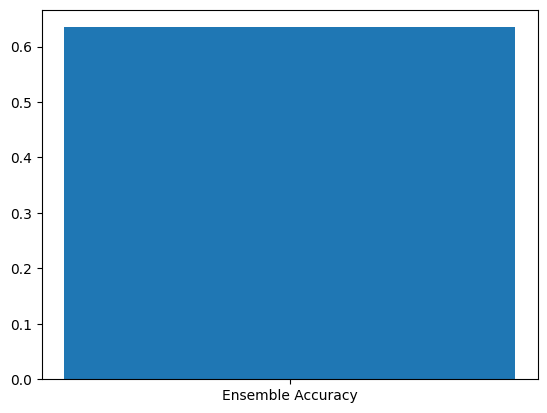

<Figure size 1000x600 with 0 Axes>

In [103]:
accuracy = (selected_w_answers["answer"] == selected_w_answers["selected_choice"]).mean()

print(accuracy)

plt.bar(x = ["Ensemble Accuracy"], height = [accuracy])
plt.figure(figsize=(10, 6))
plt.show()